# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *

plt.style.use('./Figures/paper.mplstyle')

In [2]:
# Define folder with data
root = "/home/thomas/Desktop/ALLDATA"

print("Path to data is: %s"%root)
print(f'Found {len(glob.glob(root+"/*"))} rats in the data folder')

Path to data is: /home/thomas/Desktop/ALLDATA
Found 34 rats in the data folder


In [3]:
rat_markers = {}
sequence = {}

animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
              'RatF30', 'RatF31', 'RatF32', 'RatF33', 'RatM30', 'RatM31', 'RatM32', 
              'RatF40', 'RatF41', 'RatF42', 'RatM40', 'RatM41', 'RatM42', 'RatM43', 
                'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52', 'RatM53', 'RatM54']

intact_rats = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
                    'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']

lesioned_rats = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']


m, f, l = 0, 0, 0
male_palette = create_teal_palette(num_shades=len([x for x in intact_rats if 'M' in x]))
female_palette = create_blue_violet_palette(num_shades=len([x for x in intact_rats if 'F' in x]), start_intensity=80)
palette = create_kiwi_green_palette(num_shades=len(lesioned_rats))
for index, animal in enumerate(intact_rats):
    if fnmatch.fnmatch(animal, 'RatF*'):
        rat_markers[animal]=[female_palette[f], 'o', '-']
        f += 1
    elif fnmatch.fnmatch(animal, 'RatM*'):
        rat_markers[animal]=[male_palette[m], 'o', '-']
        m += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")

for index, animal in enumerate(lesioned_rats):
    if fnmatch.fnmatch(animal, 'Rat*'):
        rat_markers[animal]=[palette[l], 'o']
        l += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")


# Figure 3A Schematics of three action cost conditions with increasing platform distances.
# Figure 3D Same with treadmill velocity.

In [4]:
def get_run_speed(example_rat='RatM00', example_session='RatM00_2021_07_22_16_13_03', lesioned_animals=False):

    if not lesioned_animals:
        animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']
    else:
        animalList = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']

    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    run_speeds = {k: {a: [] for a in conds} for k in animalList}
    median_run_speeds = {k: {a: [] for a in conds} for k in animalList}

    for cond, sessionlist in zip(conds, [dist60, dist90, dist120, TM20, TM10, TM2, TMrev10, TMrev20]):
        for animal in animalList:
            for session in matchsession(animal, sessionlist):
                params = get_from_pickle(root, animal, session, name="params.p")
                for elem in sequence[animal, session]:
                    if get_block(sequence[animal, session][elem][0]) <= 1:
                        if sequence[animal, session][elem][1] == 'run':
                            tm_speed = params['treadmillSpeed'][get_block(sequence[animal, session][elem][0])]
                            run_speeds[animal][cond].append(abs(sequence[animal, session][elem][-1]) - tm_speed)
    for animal in animalList:
        for cond in conds:
            median_run_speeds[animal][cond] = np.median(run_speeds[animal][cond])

    # for Fig 5
    if not lesioned_animals:
        pickle.dump([np.median(run_speeds[example_rat][cond]) for cond in conds], open("picklejar/example_rat_run_speeds.p", "wb"))

        # example session
        example_session_run_speeds = []
        params = get_from_pickle(root, example_rat, example_session, name="params.p")
        for elem in sequence[example_rat, example_session]:
            if get_block(sequence[example_rat, example_session][elem][0]) <= 1:
                if sequence[example_rat, example_session][elem][1] == 'run':
                    tm_speed = params['treadmillSpeed'][get_block(sequence[example_rat, example_session][elem][0])]
                    example_session_run_speeds.append(abs(sequence[example_rat, example_session][elem][-1]) - tm_speed)

        return median_run_speeds, np.median(example_session_run_speeds)
    return median_run_speeds, 0

run_speeds, ex_run_speed = get_run_speed()
run_speeds_lesion, _ = get_run_speed(lesioned_animals=True)


PLOT_PARAMS = {
    'run_speed': dict(fit=run_speeds, ex_fit=ex_run_speed, yticks=[20, 40, 60, 80, 100, ], ylabel='Run Speed', start='med', end=1),
    'run_speed_lesion': dict(fit=run_speeds_lesion, ex_fit=0, yticks=[20, 40, 60, 80, 100, ], ylabel='Run Speed', start='med', end=1)
}


In [10]:

def plot_model_parameter(param_name, dist_or_tm='dist', show_ex=False, ax=None, show_xlabel=False, show_ylabel=False, hide_y=False,
                         lesioned_animals=False):

    if not lesioned_animals:
        animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']
    else:
        animalList = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]
    if dist_or_tm == 'dist':
        x = [0, 1, 2]
        conds = ["60", "90", "120"]
        xticklabels = ["60", "90", "120"]
        _ = r'$d$'
        xlabel = f'{_} (cm)'
    elif dist_or_tm == 'tm':
        x = [0, 1, 2, 3, 4]
        conds = ["20", "10", "2", "rev10", "rev20"]
        xticklabels = ["20", "10", "±2", "-10", "-20"]
        _ = r'$v_{belt}$'
        xlabel = f'{_} (cm/s)'

    for animal in animalList:
        ax.plot(x, [params['fit'][animal][cond] for cond in conds], 
                    color=rat_markers[animal][0], marker=rat_markers[animal][1], lw=.75,
                    markersize=2, zorder=8 if animal=='RatM00' else 5)
        
    if show_ex:
        ax.plot(2, params['ex_fit'], color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')


    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)

    ax.set_xlim(x[0], x[-1])
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)
    if show_xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel(" ")

    ax.set_ylim(params['yticks'][0], params['yticks'][-1])
    ax.set_yticks(params['yticks'])
    if param_name not in ['run_speed', 'run_speed_lesion']:
        ax.yaxis.set_major_formatter('{x:<5.2f}')
    if show_ylabel:
        ax.set_ylabel(params['ylabel'])
    if hide_y:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False, labelleft=False)

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(params['fit'], ax=ax, dist_or_tm=dist_or_tm, animalList=animalList, err='percentile')



p_s=0.000, p_i=0.000, obs_slope=16.543, obs_intercept=37.436
p_s=0.000, p_i=0.000, obs_slope=7.420, obs_intercept=54.469
p_s=0.000, p_i=0.000, obs_slope=15.588, obs_intercept=35.315
p_s=0.000, p_i=0.000, obs_slope=6.463, obs_intercept=48.832


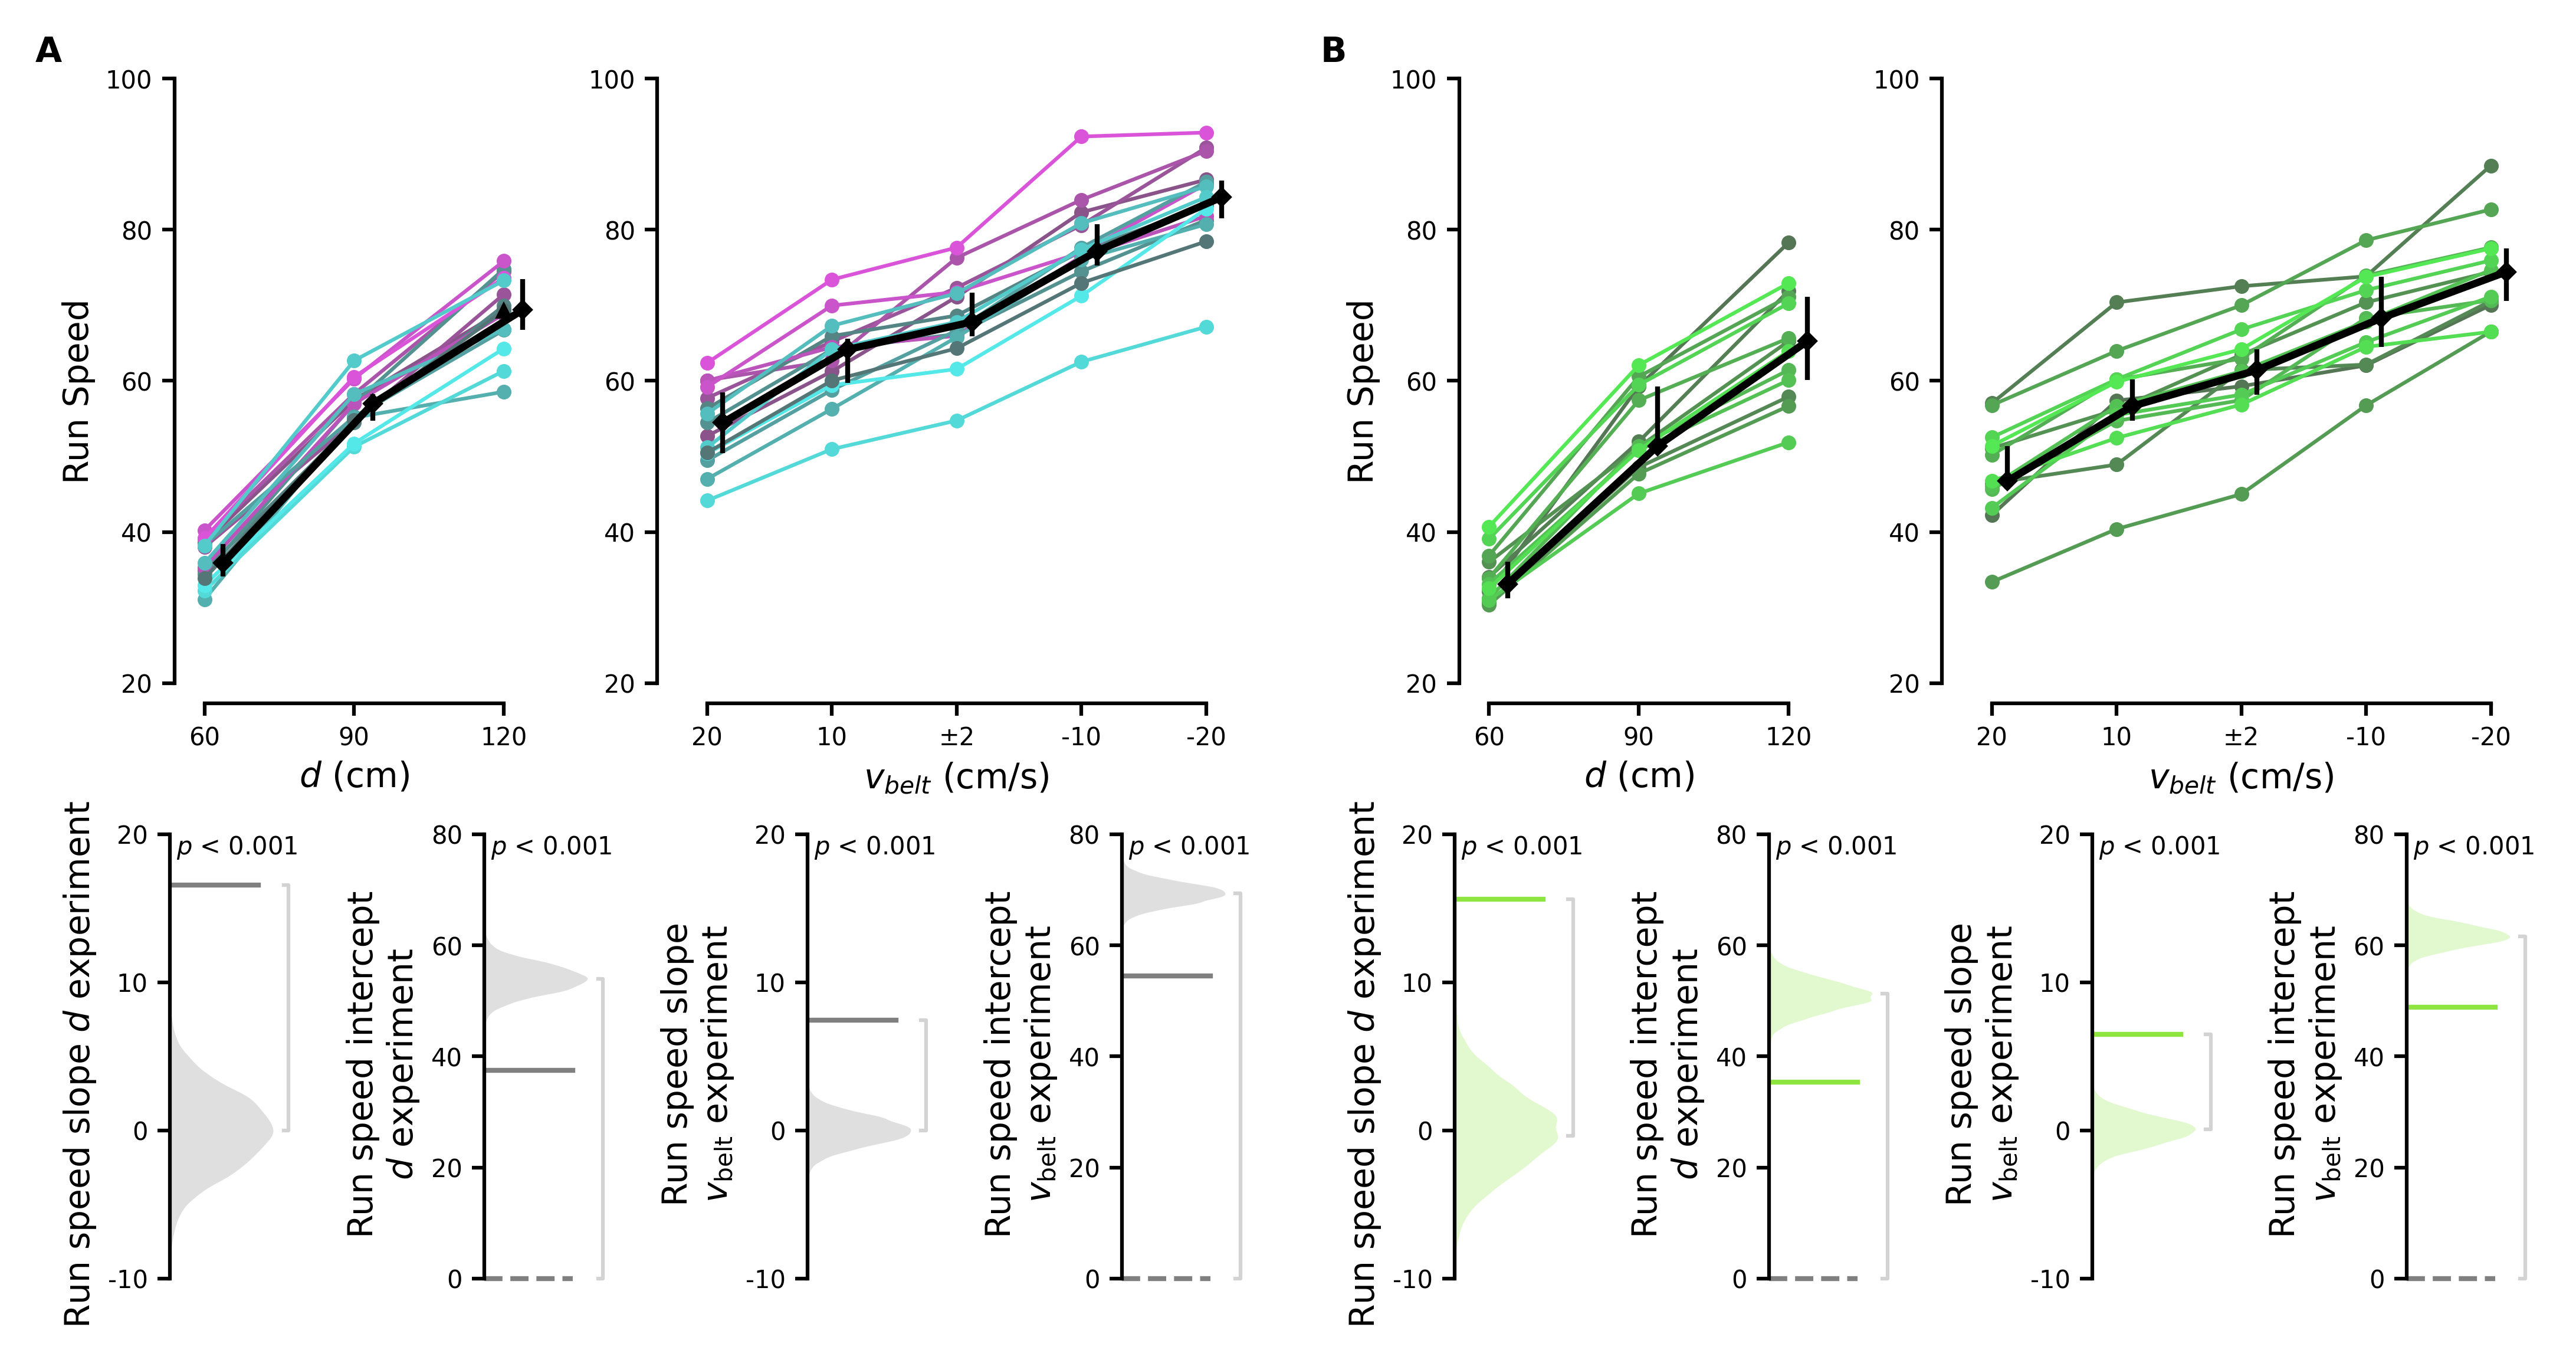

In [11]:
fig = plt.figure(figsize=(cm2inch(18), cm2inch(9)),
                 constrained_layout=True, facecolor='w', dpi=600)

h_ratio = [1, .66]
gs0 = fig.add_gridspec(1, 3, width_ratios=[1, .05, 1])

left = gs0[0].subgridspec(2, 1, height_ratios=h_ratio)
left_row1 = left[0].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_intact = plt.subplot(left_row1[0])
ax_tm_intact = plt.subplot(left_row1[1])

left_row2 = left[1].subgridspec(1, 4)
ax_slope_dist_intact = plt.subplot(left_row2[0])
ax_intercept_dist_intact = plt.subplot(left_row2[1])
ax_slope_tm_intact = plt.subplot(left_row2[2])
ax_intercept_tm_intact = plt.subplot(left_row2[3])


right = gs0[2].subgridspec(2, 1, height_ratios=h_ratio)
right_row1 = right[0].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_lesion = plt.subplot(right_row1[0])
ax_tm_lesion = plt.subplot(right_row1[1])

right_row2 = right[1].subgridspec(1, 4)
ax_slope_dist_lesion = plt.subplot(right_row2[0])
ax_intercept_dist_lesion = plt.subplot(right_row2[1])
ax_slope_tm_lesion = plt.subplot(right_row2[2])
ax_intercept_tm_lesion = plt.subplot(right_row2[3])

_ = r'$d$'
__ = r'$v_{\mathrm{belt}}$'

plot_model_parameter('run_speed', dist_or_tm='dist', show_ex=True, ax=ax_dist_intact, 
                         show_xlabel=True, show_ylabel=True)

plot_model_parameter('run_speed', dist_or_tm='tm', show_ex=False, ax=ax_tm_intact, 
                         show_xlabel=True, show_ylabel=False)

regression_permutation(run_speeds, dist_or_tm='dist',
                       varname_slope=f'Run speed slope {_} experiment',
                        varname_intercept=f'Run speed intercept\n{_} experiment',
                        ax_slope=ax_slope_dist_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_intact, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds, dist_or_tm='tm',
                       varname_slope=f'Run speed slope\n{__} experiment',
                        varname_intercept=f'Run speed intercept\n{__} experiment',
                        ax_slope=ax_slope_tm_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_intact, y_ticks_intercept=[0, 20, 40, 60, 80])



plot_model_parameter('run_speed_lesion', dist_or_tm='dist', show_ex=True, ax=ax_dist_lesion, lesioned_animals=True,
                         show_xlabel=True, show_ylabel=True)

plot_model_parameter('run_speed_lesion', dist_or_tm='tm', show_ex=False, ax=ax_tm_lesion, lesioned_animals=True,
                         show_xlabel=True, show_ylabel=False)

regression_permutation(run_speeds_lesion, dist_or_tm='dist', lesioned_animals=True,
                        varname_slope=f'Run speed slope {_} experiment',
                        varname_intercept=f'Run speed intercept\n{_} experiment',
                        ax_slope=ax_slope_dist_lesion, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_lesion, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds_lesion, dist_or_tm='tm', lesioned_animals=True,
                       varname_slope=f'Run speed slope\n{__} experiment',
                        varname_intercept=f'Run speed intercept\n{__} experiment',
                        ax_slope=ax_slope_tm_lesion, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_lesion, y_ticks_intercept=[0, 20, 40, 60, 80])

add_all_letters([ax_dist_intact, ax_dist_lesion], ["A", "B"])

plt.savefig("./Figures_paper/Figure_SXXXX.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_SXXXX.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)